# NYC Taxi Fare Prediction (Regression)
**Target:** `fare_amount`

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Libraries loaded ✓')

Libraries loaded ✓


## 2. Load Dataset

In [2]:
try:
    df = pd.read_csv('train.csv', nrows=100000)
except FileNotFoundError:
    print("'train.csv' not found."); raise
print(f"Shape: {df.shape}")
df.head()

Shape: (100000, 8)


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2013-07-06 17:00:00.0000000,12.95,2013-05-08 11:54:00 UTC,-73.937638,40.757771,-73.951124,40.800715,1.0
1,2013-07-06 17:00:00.0000001,14.29,2013-09-28 16:14:00 UTC,-73.764786,40.745934,-73.835740,40.731149,1.0
2,2013-07-06 17:00:00.0000002,5.32,2011-11-09 09:15:00 UTC,-73.830402,40.707228,-73.835251,40.696173,2.0
3,2013-07-06 17:00:00.0000003,9.88,2009-08-01 19:31:00 UTC,-73.870402,40.738507,-73.906957,40.716808,1.0
4,2013-07-06 17:00:00.0000004,7.05,2014-01-19 17:19:00 UTC,-74.003194,40.710321,-74.029396,40.708558,2.0


## 3. Identify Data Types

In [3]:
print("Column data types:")
print(df.dtypes)
print(f"\nNumeric : {df.select_dtypes(include='number').columns.tolist()}")
print(f"Object  : {df.select_dtypes(include='object').columns.tolist()}")

Column data types:
key                   object
fare_amount          float64
pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count      float64
dtype: object

Numeric : ['fare_amount', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']
Object  : ['key', 'pickup_datetime']


## 4. Descriptive Statistics

In [4]:
df.describe().round(2)

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,100000.00,100000.00,100000.00,100000.00,100000.00,98002.00
mean,11.66,-73.91,40.74,-73.90,40.74,1.86
std,18.36,0.42,0.06,0.09,0.07,1.34
min,-1.00,-99.94,40.63,-74.05,40.63,0.00
25%,8.00,-73.98,40.69,-73.98,40.68,1.00
50%,10.71,-73.90,40.74,-73.90,40.74,1.00
75%,13.93,-73.83,40.80,-73.82,40.80,2.00
max,999.00,-60.12,40.85,-73.75,40.85,10.00


## 5. Handle Missing Values

In [5]:
print("Missing values:"); print(df.isnull().sum())
df.dropna(inplace=True)
print(f"\nShape after drop: {df.shape} | Remaining NaNs: {df.isnull().sum().sum()}")

Missing values:
key                     0
fare_amount             0
pickup_datetime         0
pickup_longitude        0
pickup_latitude         0
dropoff_longitude       0
dropoff_latitude        0
passenger_count      1998
dtype: int64

Shape after drop: (98002, 8) | Remaining NaNs: 0


## 6. Handle Duplicates

In [6]:
print(f"Duplicates: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Shape after dedup: {df.shape}")

Duplicates: 0
Shape after dedup: (98002, 8)


## 7. Outlier Detection & Removal

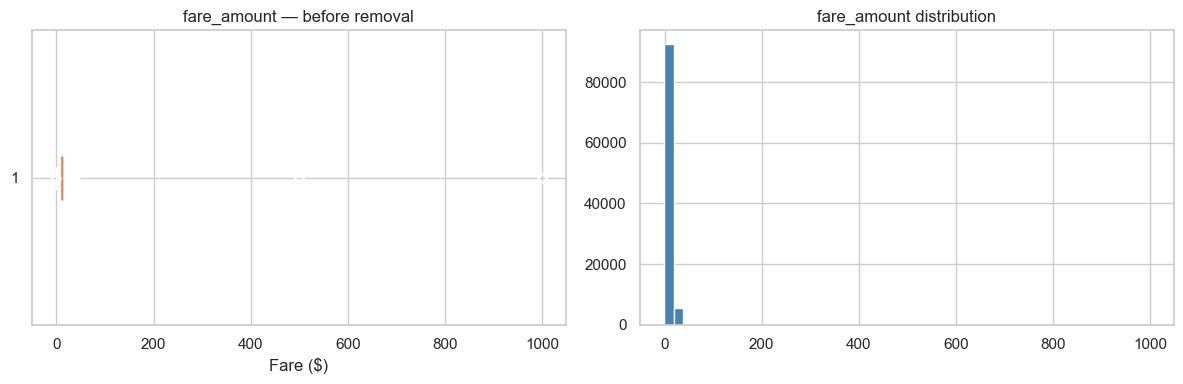

Removed: 1588 rows | Shape: (96414, 8)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['fare_amount'].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='steelblue',alpha=0.6))
axes[0].set_title('fare_amount — before removal'); axes[0].set_xlabel('Fare ($)')
axes[1].hist(df['fare_amount'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('fare_amount distribution')
plt.tight_layout(); plt.show()

before = len(df)
df = df[(df['fare_amount'] > 0) & (df['fare_amount'] <= 250)]
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] <= 6)]
nyc = {'min_lng':-74.5,'max_lng':-72.8,'min_lat':40.5,'max_lat':41.8}
df = df[df['pickup_longitude'].between(nyc['min_lng'],nyc['max_lng']) &
        df['dropoff_longitude'].between(nyc['min_lng'],nyc['max_lng']) &
        df['pickup_latitude'].between(nyc['min_lat'],nyc['max_lat']) &
        df['dropoff_latitude'].between(nyc['min_lat'],nyc['max_lat'])]
Q1,Q3 = df['fare_amount'].quantile([0.25,0.75]); IQR=Q3-Q1
df = df[df['fare_amount'].between(Q1-1.5*IQR, Q3+1.5*IQR)]
print(f"Removed: {before-len(df)} rows | Shape: {df.shape}")

## 8. Feature Engineering

In [8]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'].str.slice(0,16), format='%Y-%m-%d %H:%M')
df['hour']      = df['pickup_datetime'].dt.hour
df['day']       = df['pickup_datetime'].dt.day
df['month']     = df['pickup_datetime'].dt.month
df['year']      = df['pickup_datetime'].dt.year
df['dayofweek'] = df['pickup_datetime'].dt.dayofweek

def haversine(lat1,lon1,lat2,lon2):
    R=6371.0; dlat=np.radians(lat2-lat1); dlon=np.radians(lon2-lon1)
    a=np.sin(dlat/2)**2+np.cos(np.radians(lat1))*np.cos(np.radians(lat2))*np.sin(dlon/2)**2
    return R*2*np.arctan2(np.sqrt(a),np.sqrt(1-a))

df['trip_distance_km'] = haversine(df['pickup_latitude'],df['pickup_longitude'],
                                    df['dropoff_latitude'],df['dropoff_longitude'])
df = df[df['trip_distance_km'] > 0]
print(f"Final shape: {df.shape}")

Final shape: (96414, 14)


## 9. Visualizations & Insights

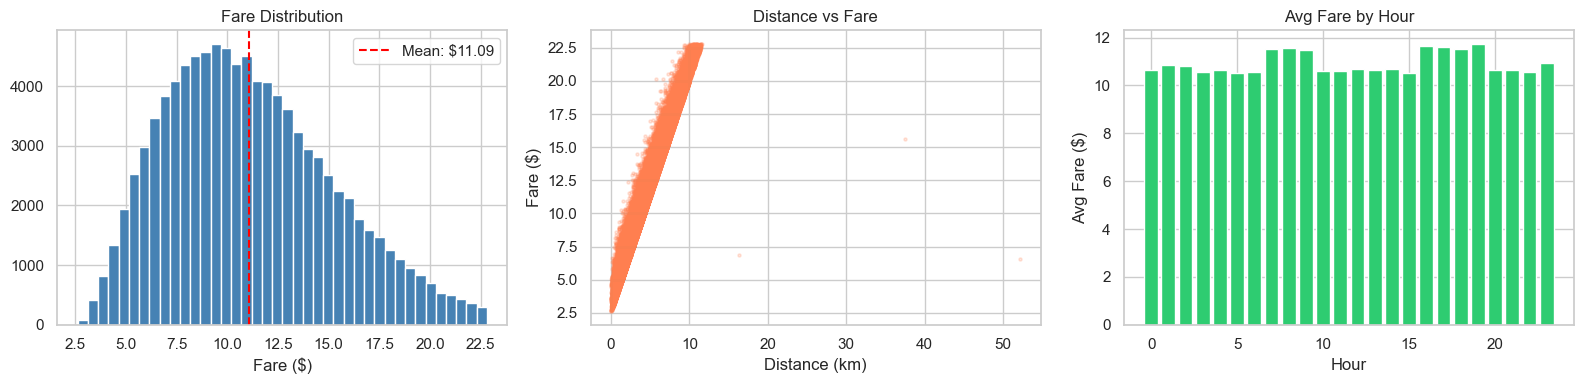

Insights:
1. Fare is right-skewed — most trips cost $5–$15.
2. Strong positive correlation between distance and fare.
3. Late-night and rush hours have slightly higher average fares.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df['fare_amount'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(df['fare_amount'].mean(), color='red', linestyle='--', label=f"Mean: ${df['fare_amount'].mean():.2f}")
axes[0].set_title('Fare Distribution'); axes[0].set_xlabel('Fare ($)'); axes[0].legend()

axes[1].scatter(df['trip_distance_km'], df['fare_amount'], alpha=0.2, s=5, color='coral')
axes[1].set_title('Distance vs Fare'); axes[1].set_xlabel('Distance (km)'); axes[1].set_ylabel('Fare ($)')

hourly = df.groupby('hour')['fare_amount'].mean()
axes[2].bar(hourly.index, hourly.values, color='#2ecc71', edgecolor='white')
axes[2].set_title('Avg Fare by Hour'); axes[2].set_xlabel('Hour'); axes[2].set_ylabel('Avg Fare ($)')

plt.tight_layout(); plt.show()
print("""Insights:
1. Fare is right-skewed — most trips cost $5–$15.
2. Strong positive correlation between distance and fare.
3. Late-night and rush hours have slightly higher average fares.""")

## 10. Scale Features

In [10]:
X = df.drop(columns=['key','fare_amount','pickup_datetime'])
y = df['fare_amount']
FEATURE_COLS = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f"Features: {FEATURE_COLS}")
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Features: ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'hour', 'day', 'month', 'year', 'dayofweek', 'trip_distance_km']
Train: 77131 | Test: 19283


## 11. Model Building

In [11]:
models = {
    'Linear Regression' : LinearRegression(),
    'Random Forest'     : RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'LightGBM'          : lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=10, random_state=42)
}
results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    yp = model.predict(X_test_sc)
    results[name] = {'RMSE':round(np.sqrt(mean_squared_error(y_test,yp)),3),
                     'MAE' :round(mean_absolute_error(y_test,yp),3),
                     'R²'  :round(r2_score(y_test,yp),4)}
    print(f'✓ {name}')

✓ Linear Regression
✓ Random Forest
✓ Gradient Boosting
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001019 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1365
[LightGBM] [Info] Number of data points in the train set: 77131, number of used features: 11
[LightGBM] [Info] Start training from score 11.091858
✓ LightGBM


## 12. Model Comparison

                    RMSE    MAE      R²
Gradient Boosting  0.654  0.495  0.9742
Random Forest      0.658  0.496  0.9739
LightGBM           0.664  0.496  0.9734
Linear Regression  1.034  0.676  0.9356


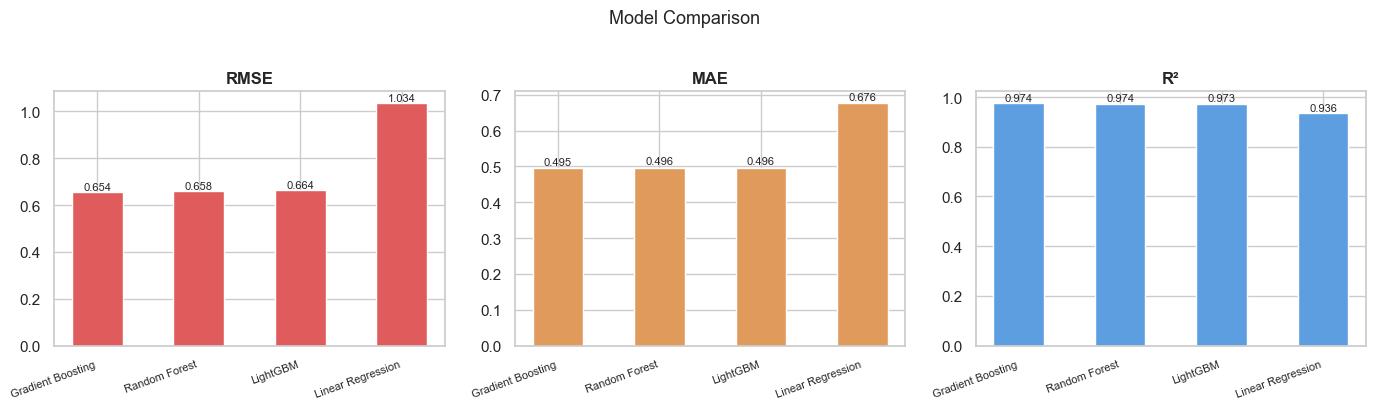

In [12]:
res_df = pd.DataFrame(results).T.sort_values('R²', ascending=False)
print(res_df)
fig, axes = plt.subplots(1,3,figsize=(14,4))
for ax,metric,color in zip(axes,['RMSE','MAE','R²'],['#e05c5c','#e09b5c','#5c9ee0']):
    vals=res_df[metric]; bars=ax.bar(vals.index,vals.values,color=color,edgecolor='white',width=0.5)
    ax.set_title(metric,fontweight='bold'); ax.set_xticklabels(vals.index,rotation=20,ha='right',fontsize=8)
    for b,v in zip(bars,vals.values): ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.01,f'{v:.3f}',ha='center',fontsize=8)
plt.suptitle('Model Comparison',fontsize=13,y=1.02); plt.tight_layout(); plt.show()

---
## 13. Predict Fare for Your Own Input
**Edit the values below and run the cell to get a fare prediction.**

In [14]:
pickup_longitude  = -73.985    # Pickup longitude (NYC range: -74.5 to -72.8)
pickup_latitude   = 40.758     # Pickup latitude  (NYC range: 40.5 to 41.8)
dropoff_longitude = -73.950    # Dropoff longitude
dropoff_latitude  = 40.782     # Dropoff latitude
passenger_count   = 1          # Number of passengers (1–6)
pickup_hour       = 18         # Hour of pickup (0–23)
pickup_day        = 15         # Day of month (1–31)
pickup_month      = 6          # Month (1–12)
pickup_year       = 2024       # Year
pickup_dayofweek  = 4          # Day of week (0=Mon, 6=Sun)

# ── Auto-calculated (do not change) ──────
dist_km = haversine(pickup_latitude, pickup_longitude, dropoff_latitude, dropoff_longitude)

new_input = pd.DataFrame([{
    'pickup_longitude' : pickup_longitude,
    'pickup_latitude'  : pickup_latitude,
    'dropoff_longitude': dropoff_longitude,
    'dropoff_latitude' : dropoff_latitude,
    'passenger_count'  : passenger_count,
    'hour'             : pickup_hour,
    'day'              : pickup_day,
    'month'            : pickup_month,
    'year'             : pickup_year,
    'dayofweek'        : pickup_dayofweek,
    'trip_distance_km' : dist_km
}])[FEATURE_COLS]

new_scaled = scaler.transform(new_input)

print("=" * 45)
print("        TAXI FARE PREDICTION RESULTS")
print("=" * 45)
print(f"  Trip Distance     : {dist_km:.2f} km")
print(f"  Passengers        : {passenger_count}")
print(f"  Pickup Hour       : {pickup_hour}:00")
print("-" * 45)
for name, model in models.items():
    pred = model.predict(new_scaled)[0]
    print(f"  {name:<22}: ${pred:.2f}")
print("=" * 45)

        TAXI FARE PREDICTION RESULTS
  Trip Distance     : 3.98 km
  Passengers        : 1
  Pickup Hour       : 18:00
---------------------------------------------
  Linear Regression     : $10.47
  Random Forest         : $10.96
  Gradient Boosting     : $10.93
  LightGBM              : $10.94
